# Urban Flow Analytics — Task 2.1: Upfront Pricing Engine
## Real-Time Pre-Trip Base Fare Prediction

This notebook implements the end-to-end machine learning pipeline for **Task 2.1 (Upfront Fare Pricing)**.
The objective is to compute a deterministic, fair upfront base fare quote for a passenger *before* the trip commences, eliminating metering uncertainty while maintaining high operational revenue alignment.

### Operational Framework & Key Criteria:
1. **Zero Information Leakage:** Features are strictly limited to attributes observable *before* passenger pickup (e.g., origin/destination zones, scheduled pickup time, trip distance, rate class). Post-trip attributes (`trip_duration_minutes`, `trip_speed_mph`, `driver_tip_payment`, `tolls`, `dropoff_timestamp`) are strictly excluded.
2. **Chronological Splitting:** Models are trained on historical records (Apr 2025 – Jan 2026), tuned on validation records (Feb 2026), and evaluated out-of-time on unseen future records (Mar 2026).
3. **Core Evaluation Metrics:** Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), Coefficient of Determination ($R^2$), and Root Mean Squared Logarithmic Error (RMSLE).


In [1]:
import sys
from pathlib import Path

# Set project root
project_root = Path.cwd().resolve()
if project_root.name in ("notebooks", "src", "tests"):
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import time
import duckdb
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import Ridge

from src.features import prepare_upfront_pricing_features
from src.models import (
    evaluate_regression,
    load_model,
    predict_lightgbm,
    predict_xgboost,
    save_model,
    train_lightgbm,
    train_linear_baseline,
    train_xgboost,
)
from src.utils import (
    MODELS_DIR,
    PROCESSED_DATA_DIR,
    calculate_regression_metrics,
    timer,
)

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
print("Libraries imported and runtime configured successfully.")


Libraries imported and runtime configured successfully.


## 1. Chronological Split Verification & Integrity Check

We verify that the temporal splits (`train`, `val`, `test`) maintain strict chronological ordering with zero temporal leakage.


In [2]:
split_summary_path = PROCESSED_DATA_DIR / "split_summary.csv"
if split_summary_path.exists():
    df_splits = pd.read_csv(split_summary_path)
    display(df_splits)
else:
    print("split_summary.csv not found, checking processed directory...")


,split,row_count,percentage
0,test,3777555,8.50
1,train,37459831,84.26
2,val,3221802,7.25


## 2. Target Variable Analysis (`base_fare`)

We examine the distribution, summary statistics, and structural pricing modes of `base_fare` in the training corpus.
Key structural phenomena include:
- Standard metered trips scaling with distance.
- JFK Flat-Rate modes ($52 and $70 regulated flat fares).
- Corporate / voucher $0 trips.


Target Variable (base_fare) Descriptive Statistics:
count    100000.000000
mean         20.750433
std          18.327435
min           0.000000
1%            3.700000
5%            5.800000
50%          14.900000
95%          62.500000
99%          82.302000
max         900.000000
Name: base_fare, dtype: float64


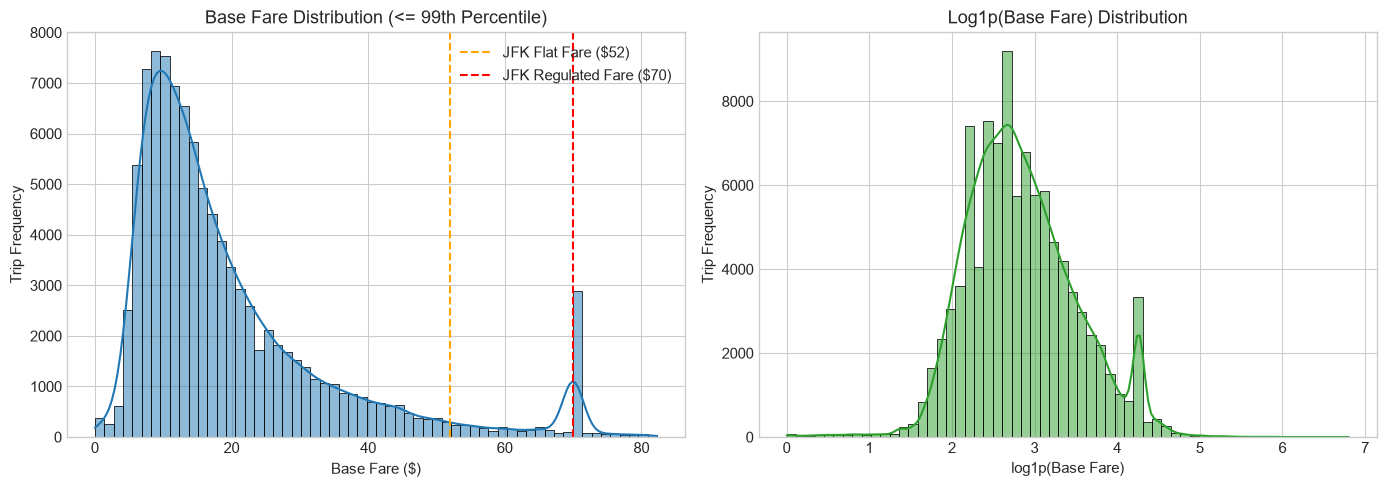

In [3]:
df_sample = pd.read_csv(PROCESSED_DATA_DIR / "train_sample.csv", nrows=100000)
fare_stats = df_sample["base_fare"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
print("Target Variable (base_fare) Descriptive Statistics:")
print(fare_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale distribution (trimmed at 99th percentile for visualization)
p99 = df_sample["base_fare"].quantile(0.99)
sns.histplot(df_sample[df_sample["base_fare"] <= p99]["base_fare"], bins=60, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Base Fare Distribution (<= 99th Percentile)")
axes[0].set_xlabel("Base Fare ($)")
axes[0].set_ylabel("Trip Frequency")
axes[0].axvline(52.0, color="orange", linestyle="--", label="JFK Flat Fare ($52)")
axes[0].axvline(70.0, color="red", linestyle="--", label="JFK Regulated Fare ($70)")
axes[0].legend()

# Log-transformed distribution
sns.histplot(np.log1p(df_sample["base_fare"]), bins=60, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Log1p(Base Fare) Distribution")
axes[1].set_xlabel("log1p(Base Fare)")
axes[1].set_ylabel("Trip Frequency")

plt.tight_layout()
plt.show()


## 3. Pre-Trip Feature Matrix Assembler

Features are generated strictly before trip start using `prepare_upfront_pricing_features()`:
- **Routing & Distance:** `distance_miles`, `log_distance`
- **Spatial / Geographic:** `origin_loc_id`, `dest_loc_id`, `is_same_zone`, `is_airport_pickup`, `is_airport_dropoff`, `is_airport_trip`, `is_ewr_trip`, `is_interborough`, `is_manhattan_intra`
- **Temporal / Calendar:** `pickup_hour`, `pickup_dayofweek`, `is_weekend`, `pickup_month`, `pickup_day`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `is_rush_hour`, `is_late_night`
- **Operational & Regulatory:** `rate_class_id`, `is_standard_rate`, `is_jfk_flat_rate`, `is_newark_rate`, `is_negotiated_rate`, `rider_count`, `provider_code`, `fare_settlement_method`

**Zero Leakage Guarantee:** Attributes determined post-pickup (`trip_duration_minutes`, `trip_speed_mph`, `driver_tip_payment`, `toll_total`, `charge_total`) are completely excluded.


In [4]:
# Load training sample (100K fast benchmark) and validation sample
df_train_raw = pd.read_csv(PROCESSED_DATA_DIR / "train_sample.csv")
df_val_raw = pd.read_csv(PROCESSED_DATA_DIR / "val_sample.csv")

feat_train = prepare_upfront_pricing_features(df_train_raw, include_target=True)
feat_val = prepare_upfront_pricing_features(df_val_raw, include_target=True)

X_train = feat_train.drop(columns=["base_fare"])
y_train = feat_train["base_fare"]
X_val = feat_val.drop(columns=["base_fare"])
y_val = feat_val["base_fare"]

cat_cols = ["origin_loc_id", "dest_loc_id", "rate_class_id", "provider_code", "fare_settlement_method"]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"Engineered feature count: {X_train.shape[1]}")
print("Forbidden columns present check:", [c for c in ["dropoff_timestamp", "trip_duration_minutes", "trip_speed_mph", "driver_tip_payment"] if c in X_train.columns])


X_train shape: (100000, 30), y_train shape: (100000,)
X_val shape:   (100000, 30), y_val shape:   (100000,)
Engineered feature count: 30
Forbidden columns present check: []


## 4. Benchmark Model: Ridge Linear Regression

We train an interpretable $L_2$-regularized Ridge linear regression baseline on numeric features to establish a minimum viable performance benchmark.


In [5]:
with timer("Training Ridge Linear Regression Baseline"):
    ridge_model = train_linear_baseline(X_train, y_train, alpha=1.0)

ridge_val_preds = ridge_model.predict(X_val[ridge_model.numeric_cols_])
ridge_metrics = evaluate_regression(y_val, ridge_val_preds, label="Ridge Linear Baseline")

print("Ridge Baseline Validation Metrics:")
for k, v in ridge_metrics.items():
    print(f"  {k}: {v}")


[2026-09-11 01:14:45] START: Training Ridge Linear Regression Baseline
[2026-09-11 01:14:45] END:   Training Ridge Linear Regression Baseline - Elapsed: 0.05s (0.00m)
Ridge Baseline Validation Metrics:
  rmse: 8.966
  mae: 4.8252
  r2: 0.74
  rmsle: 0.3367
  mape: 73.49
  model_label: Ridge Linear Baseline


## 5. Primary Production Model: LightGBM Upfront Fare Engine

LightGBM is deployed as our primary regressor due to its histogram-based binning, native categorical partitioning for NYC taxi zone IDs, and computational efficiency.
We train with early stopping on validation RMSE.


In [6]:
with timer("Training LightGBM Primary Model"):
    lgb_model, imp_df, best_score = train_lightgbm(
        X_train, y_train,
        X_val, y_val,
        categorical_features=cat_cols,
        params={
            "objective": "regression",
            "metric": "rmse",
            "learning_rate": 0.08,
            "num_leaves": 63,
            "min_child_samples": 50,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "verbose": -1,
            "random_state": 42,
        },
        num_boost_round=400,
        early_stopping_rounds=40,
        verbose_eval=50,
    )

lgb_val_preds = predict_lightgbm(lgb_model, X_val, categorical_features=cat_cols)
lgb_metrics = evaluate_regression(y_val, lgb_val_preds, label="LightGBM Primary Model")

print("\nLightGBM Validation Metrics:")
for k, v in lgb_metrics.items():
    print(f"  {k}: {v}")


[2026-09-11 01:14:45] START: Training LightGBM Primary Model


[50]	train's rmse: 6.75041	val's rmse: 7.60236


[100]	train's rmse: 6.11697	val's rmse: 7.32441
[150]	train's rmse: 5.78295	val's rmse: 7.28907


[2026-09-11 01:14:46] END:   Training LightGBM Primary Model - Elapsed: 0.78s (0.01m)

LightGBM Validation Metrics:
  rmse: 7.2853
  mae: 3.6013
  r2: 0.8284
  rmsle: 0.2502
  mape: 71.08
  model_label: LightGBM Primary Model


## 6. Secondary Benchmark: XGBoost Regressor

To evaluate architecture tradeoffs, we train an XGBoost gradient boosted tree on the feature matrix and compare validation metrics and training duration side-by-side.


In [7]:
with timer("Training XGBoost Benchmark Model"):
    xgb_model, xgb_imp = train_xgboost(
        X_train, y_train,
        X_val, y_val,
        params={
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "learning_rate": 0.08,
            "max_depth": 6,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
            "verbosity": 0,
        },
        num_boost_round=200,
        early_stopping_rounds=30,
    )

xgb_val_preds = predict_xgboost(xgb_model, X_val)
xgb_metrics = evaluate_regression(y_val, xgb_val_preds, label="XGBoost Benchmark")

print("\nXGBoost Validation Metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v}")

# Comparison Table
comparison_df = pd.DataFrame([ridge_metrics, lgb_metrics, xgb_metrics])
display(comparison_df)


[2026-09-11 01:14:46] START: Training XGBoost Benchmark Model


[2026-09-11 01:14:49] END:   Training XGBoost Benchmark Model - Elapsed: 2.38s (0.04m)

XGBoost Validation Metrics:
  rmse: 7.5529
  mae: 3.7014
  r2: 0.8155
  rmsle: 0.2468
  mape: 89.05
  model_label: XGBoost Benchmark


,rmse,mae,r2,rmsle,mape,model_label
0,8.9660,4.8252,0.7400,0.3367,73.49,Ridge Linear Baseline
1,7.2853,3.6013,0.8284,0.2502,71.08,LightGBM Primary Model
2,7.5529,3.7014,0.8155,0.2468,89.05,XGBoost Benchmark


## 7. Hyperparameter Sensitivity & Tuning

We analyze model performance across different tree complexities (`num_leaves` $\in [31, 63, 127]$) to ensure robust generalization and avoid overfitting.


In [8]:
tuning_results = []
for nl in [31, 63, 127]:
    bst_trial, _, _ = train_lightgbm(
        X_train, y_train, X_val, y_val,
        categorical_features=cat_cols,
        params={"num_leaves": nl, "learning_rate": 0.08, "verbose": -1},
        num_boost_round=150,
        early_stopping_rounds=20,
    )
    p_trial = predict_lightgbm(bst_trial, X_val, categorical_features=cat_cols)
    m_trial = evaluate_regression(y_val, p_trial, label=f"LGBM (num_leaves={nl})")
    tuning_results.append(m_trial)

tuning_df = pd.DataFrame(tuning_results)
display(tuning_df)


,rmse,mae,r2,rmsle,mape,model_label
0,7.4294,3.6954,0.8215,0.2538,71.46,LGBM (num_leaves=31)
1,7.2853,3.6013,0.8284,0.2502,71.08,LGBM (num_leaves=63)
2,7.2438,3.5876,0.8303,0.2492,72.54,LGBM (num_leaves=127)


## 8. Out-of-Time Generalization: March 2026 Test Split Evaluation

The test split contains trip records from March 2026, strictly after all training and validation data.
Evaluating on this split verifies real-world temporal generalization under changing urban demand and seasonal shifts.


Final Out-of-Time Test Metrics (Task 2.1 - Upfront Fare):
  rmse: 8.1392
  mae: 3.6103
  r2: 0.802
  rmsle: 0.2697
  mape: 50.65
  model_label: LightGBM Out-of-Time Test (March 2026)


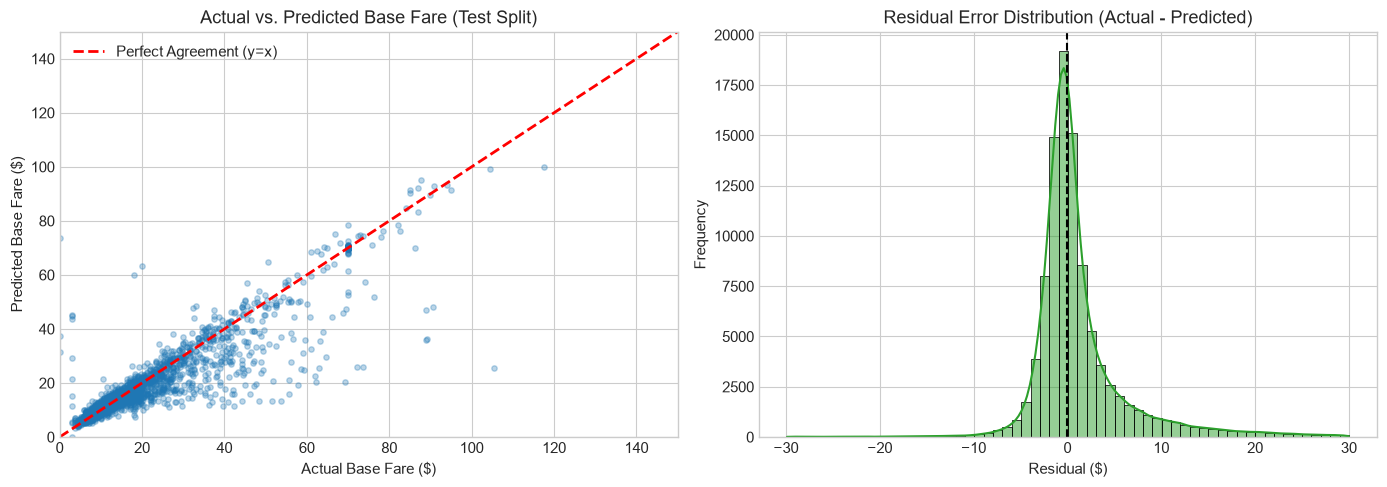

In [9]:
df_test_raw = pd.read_csv(PROCESSED_DATA_DIR / "test_sample.csv")
feat_test = prepare_upfront_pricing_features(df_test_raw, include_target=True)
X_test = feat_test.drop(columns=["base_fare"])
y_test = feat_test["base_fare"]

lgb_test_preds = predict_lightgbm(lgb_model, X_test, categorical_features=cat_cols)
test_metrics = evaluate_regression(y_test, lgb_test_preds, label="LightGBM Out-of-Time Test (March 2026)")

print("Final Out-of-Time Test Metrics (Task 2.1 - Upfront Fare):")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

# Residual Visualization
residuals = y_test - lgb_test_preds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test[:2000], lgb_test_preds[:2000], alpha=0.3, s=15, color="#1f77b4")
axes[0].plot([0, 150], [0, 150], "r--", lw=2, label="Perfect Agreement (y=x)")
axes[0].set_xlim(0, 150)
axes[0].set_ylim(0, 150)
axes[0].set_xlabel("Actual Base Fare ($)")
axes[0].set_ylabel("Predicted Base Fare ($)")
axes[0].set_title("Actual vs. Predicted Base Fare (Test Split)")
axes[0].legend()

# Residual Distribution
sns.histplot(residuals[(residuals >= -30) & (residuals <= 30)], bins=60, kde=True, ax=axes[1], color="#2ca02c")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Error Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 9. Model Interpretability & Feature Attribution

We extract Gain-based feature importance from the trained LightGBM model to understand the dominant pricing signals driving upfront estimates.


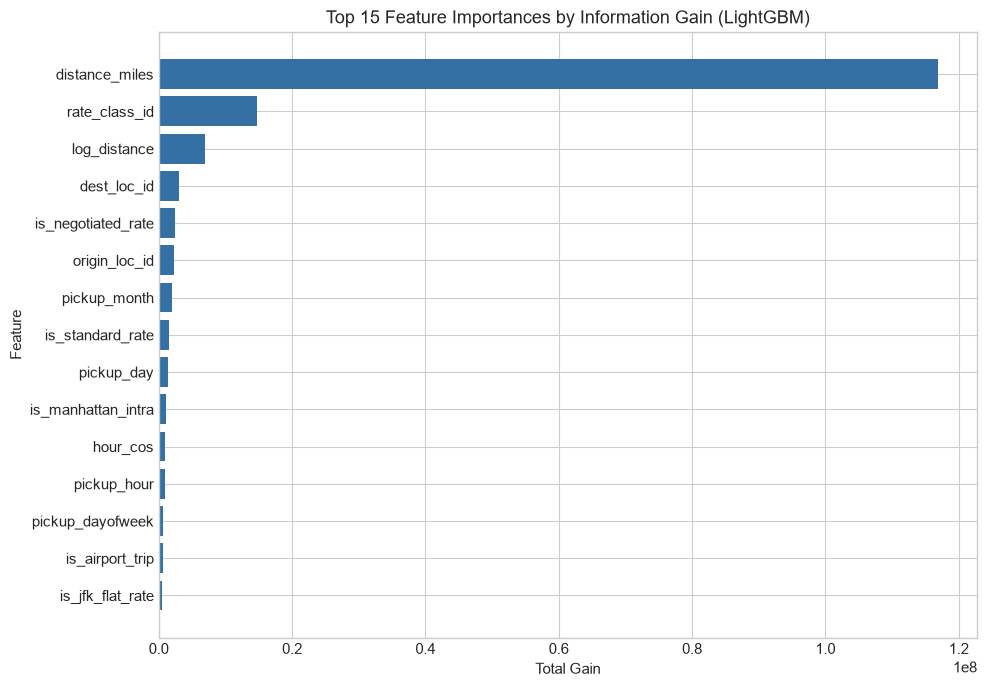

Top 10 Drivers of Upfront Base Fare:


,feature,importance_gain,importance_split
0,distance_miles,1.168953e+08,1191
1,rate_class_id,1.475761e+07,338
2,log_distance,6.978828e+06,332
3,dest_loc_id,3.084066e+06,1165
4,is_negotiated_rate,2.497481e+06,147
5,origin_loc_id,2.231719e+06,1093
6,pickup_month,2.026121e+06,836
7,is_standard_rate,1.473830e+06,257
8,pickup_day,1.426684e+06,542
9,is_manhattan_intra,1.096324e+06,49


In [10]:
plt.figure(figsize=(10, 7))
top_imp = imp_df.head(15).sort_values(by="importance_gain", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance_gain"], color="#3470a3")
plt.title("Top 15 Feature Importances by Information Gain (LightGBM)")
plt.xlabel("Total Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 Drivers of Upfront Base Fare:")
display(imp_df.head(10)[["feature", "importance_gain", "importance_split"]])


## 10. Model Serialization & Production Artifact Deployment

We persist the trained model and associated operational metadata into `models/fare_lgbm.pkl` for downstream inference services.


In [11]:
model_export_path = MODELS_DIR / "fare_lgbm.pkl"
metadata = {
    "task": "upfront_base_fare_prediction",
    "model_type": "LightGBM_Booster",
    "features": lgb_model.feature_name(),
    "categorical_features": cat_cols,
    "validation_metrics": lgb_metrics,
    "test_metrics": test_metrics,
    "version": "1.0.0",
}
save_path = save_model(lgb_model, model_export_path, metadata=metadata)
print(f"Model successfully saved to: {save_path}")

# Verify reload
loaded_model, loaded_meta = load_model(save_path)
verification_preds = predict_lightgbm(loaded_model, X_test.head(10), categorical_features=cat_cols)
print("Reloaded model verification predictions (first 5):", np.round(verification_preds[:5], 2))
print("Serialization test PASSED.")


Model successfully saved to: C:\Users\ASUS\Desktop\datathon\nexora-datathon2026\models\fare_lgbm.pkl
Reloaded model verification predictions (first 5): [14.21 13.89 15.36 12.94 70.36]
Serialization test PASSED.
